In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))  # adds /home/patroklos/delphi.ai to the path

from delphi.grad import TruncatedUnknownVarianceMSE

import torch as ch
import matplotlib.pyplot as plt
%matplotlib notebook
import numpy as np
from sklearn.linear_model import LinearRegression

ch.set_printoptions(precision=4, sci_mode=False)

In [497]:
from torch.distributions import MultivariateNormal
class TruncatedUnknownVarianceMSE(ch.autograd.Function):
    """
    Maximum Likelihood Estimator for Truncated Gaussian Regression
    using Monte Carlo (MC) estimation for the arbitrary truncation set.
    
    Optimization Variables: mu (pred) and lambda_ (1/sigma^2).
    """
    
    @staticmethod
    def forward(ctx, 
                pred, 
                targ, 
                lambda_, 
                phi, 
                num_samples=5000, 
                eps=1e-10, 
                noise=None):
        noise_var = 1.0 / lambda_
        noise_dist = MultivariateNormal(ch.zeros(1), noise_var)
        ll = noise_dist.log_prob(targ - pred)[...,None]        
        
        stacked = pred[...,None].repeat(1, num_samples, 1) # Shape: [Batch, num_samples]
        noise = noise_dist.sample(stacked.size()).squeeze(-1)
        noised = stacked + noise 

        mask = phi(noised).float()
        P_hat = mask.mean(dim=1).clamp_min(eps)
        trunc_const = ch.log(P_hat)
        
        ctx.save_for_backward(pred, targ, lambda_, noised, mask)
        ctx.eps = eps
        return -(ll - trunc_const) / pred.size(0)

    @staticmethod
    def backward(ctx, 
                 grad_output):
        pred, targ, lambda_, noised, mask = ctx.saved_tensors
        
        filtered = mask * noised
        z = filtered.sum(dim=1) / (mask.sum(dim=1) + ctx.eps)
        z_2 = filtered.pow(2).sum(dim=1) / (mask.sum(dim=1) + ctx.eps)
        
        mu_grad = lambda_ * (z - targ)
        lambda_grad = 0.5 * (targ.pow(2) - z_2).mean(0)[...,None]
        
        return mu_grad / pred.size(0), \
               None, \
               lambda_grad, \
               None, None, None, None

In [498]:
def trunc_mse(pred, targ, lambda_, phi, seed=69): 
    if seed is not None:
        ch.manual_seed(seed)
    lambda_.requires_grad = True
    loss = TruncatedUnknownVarianceMSE.apply(pred, targ, lambda_, phi, 1000)
    loss = loss.sum(0)
    loss.backward()
    return loss, pred.grad, lambda_.grad

In [499]:
W = ch.ones(1)
print(f'groud truth W:\n {W}')

X = ch.rand(1000, 1)
print(f'ground truth num samples: {X.size(0)}')
NOISE_VAR = 1 * ch.ones(1,)

Y = X @ W + ch.sqrt(NOISE_VAR) * ch.randn(X.size(0))

gt_lin_reg = LinearRegression(fit_intercept=False)
gt_lin_reg.fit(X, Y)

W_fit = ch.from_numpy(gt_lin_reg.coef_)
gt_noise_var = (ch.from_numpy(gt_lin_reg.predict(X)) - Y).var(0).item()

gt_lambda_ = 1.0/gt_noise_var
gt_v = W_fit * gt_lambda_

print(f'W fit:\n {W_fit.tolist()}')
print(f'noise var fit:\n {gt_noise_var}')

print(f'V fit:\n {gt_v.tolist()}')
print(f'lambda fit:\n {gt_lambda_}')

groud truth W:
 tensor([1.])
ground truth num samples: 1000
W fit:
 [0.9761120080947876]
noise var fit:
 1.088418960571289
V fit:
 [0.8968164324760437]
lambda fit:
 0.9187638549360811


In [500]:
def phi(X): 
    return X > 0

trunc_indices = phi(Y).nonzero()
alpha = trunc_indices.size(0) / X.size(0)
print(f'alpha:\n {alpha:.3f}')

Y_trunc = Y[trunc_indices]
X_trunc = X[trunc_indices.flatten()]

trunc_lin_reg = LinearRegression(fit_intercept=False)
trunc_lin_reg.fit(X_trunc, Y_trunc)

print(f'trunc lin reg W:\n {trunc_lin_reg.coef_}')

alpha:
 0.682
trunc lin reg W:
 [[1.655627]]


<IPython.core.display.Javascript object>


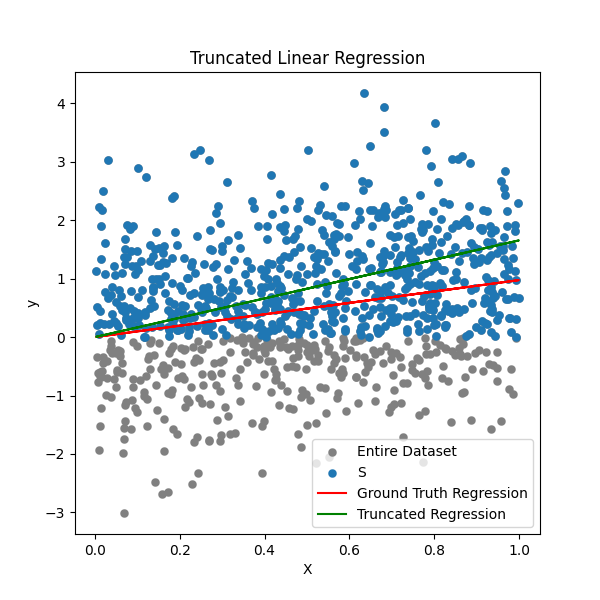

In [501]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(X, Y, linewidths=.1, color='grey', label='Entire Dataset')
ax.scatter(X_trunc, Y_trunc, linewidths=.1, label='S')
ax.plot(X.sort()[0], gt_lin_reg.predict(X.sort()[0]), color='red', label='Ground Truth Regression')
ax.plot(X.sort()[0], trunc_lin_reg.predict(X.sort()[0]), color='green', label='Truncated Regression')
ax.set_xlabel('X')
ax.set_ylabel('y')
ax.set_title('Truncated Linear Regression')
ax.legend()
plt.show()

# Vary w

<IPython.core.display.Javascript object>


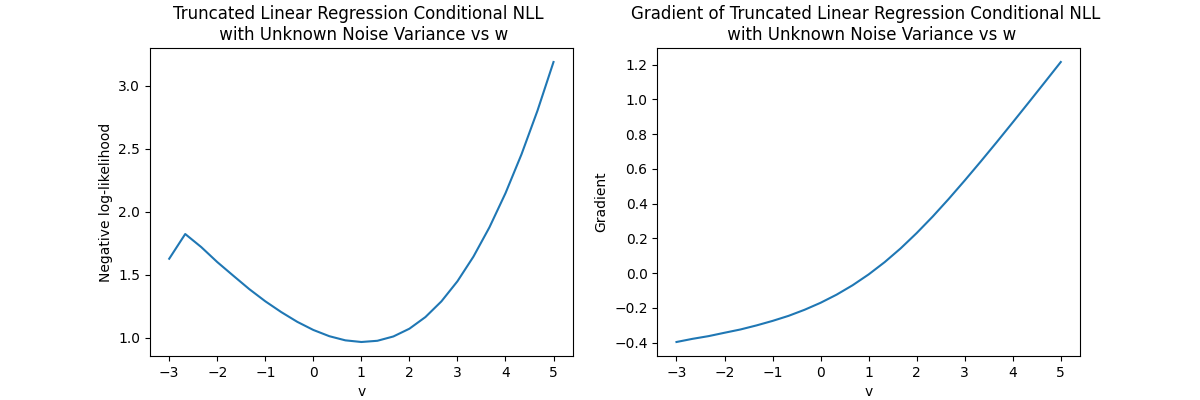

In [502]:
vs = ch.linspace(-3, 5, 25)

losses = ch.Tensor([])
grads = ch.Tensor([])

for v in vs: 
    v.requires_grad = True
    trunc_pred = X_trunc @ v.reshape(1, 1)
    trunc_pred.retain_grad()
    loss, pred_grad, lambda_grad = trunc_mse(trunc_pred, Y_trunc, ch.ones(1, 1), phi, 1000)
    losses = ch.cat([losses, loss[...,None].mean(0).detach()])
    grads = ch.cat([grads, (pred_grad * X_trunc).sum(0)])
    
# === Plot the loss landscape ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(vs, losses)
ax1.set_xlabel("v")
ax1.set_ylabel("Negative log-likelihood")
ax1.set_title("Truncated Linear Regression Conditional NLL \n with Unknown Noise Variance vs w")

ax2.plot(vs, grads)
ax2.set_xlabel("v")
ax2.set_ylabel("Gradient")
ax2.set_title("Gradient of Truncated Linear Regression Conditional NLL \n with Unknown Noise Variance vs w")

plt.show()

# Vary Sigma

<IPython.core.display.Javascript object>


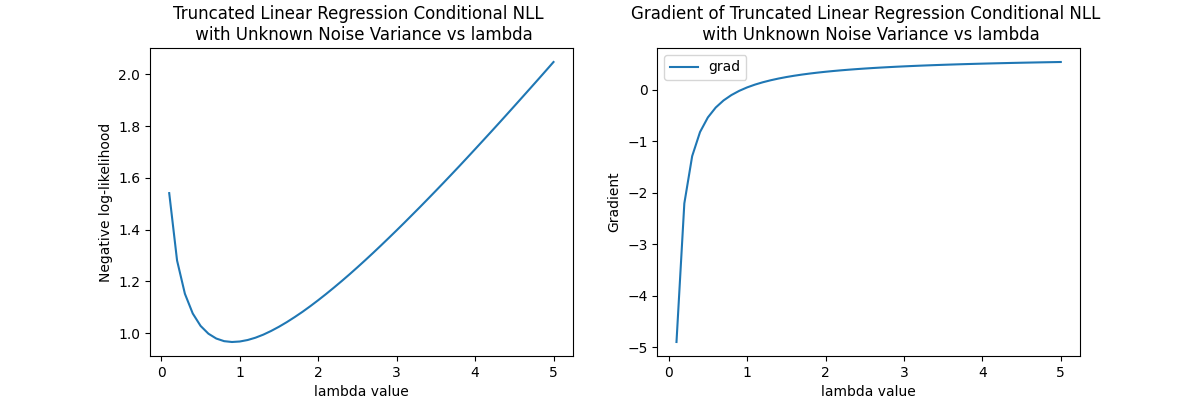

In [503]:
lambdas_ = ch.linspace(.1, 5, 50)

losses = ch.Tensor([])
grads = ch.Tensor([])

for lambda_ in lambdas_: 
    loss, pred_grad, lambda_grad = trunc_mse(X_trunc @ W.reshape(1, 1), Y_trunc, ch.Tensor([[lambda_]]), phi)
    losses = ch.cat([losses, loss[...,None].mean(0).detach()])
    grads = ch.cat([grads, lambda_grad])
    
# === Plot the loss landscape ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(lambdas_, losses)
ax1.set_xlabel("lambda value")
ax1.set_ylabel("Negative log-likelihood")
ax1.set_title("Truncated Linear Regression Conditional NLL \n with Unknown Noise Variance vs lambda")

ax2.plot(lambdas_, grads, label="grad")
ax2.set_xlabel("lambda value")
ax2.set_ylabel("Gradient")
ax2.set_title("Gradient of Truncated Linear Regression Conditional NLL \n with Unknown Noise Variance vs lambda")
ax2.legend()

plt.show()

In [478]:
lambdas_[losses.argmin()]

tensor(1.1000)

In [484]:
grads

tensor([[-5.0297],
        [-2.3310],
        [-1.4102],
        [-0.9420],
        [-0.6570],
        [-0.4650],
        [-0.3263],
        [-0.2212],
        [-0.1390],
        [-0.0726],
        [-0.0178],
        [ 0.0278],
        [ 0.0669],
        [ 0.1005],
        [ 0.1298],
        [ 0.1556],
        [ 0.1784],
        [ 0.1987],
        [ 0.2169],
        [ 0.2334],
        [ 0.2483],
        [ 0.2618],
        [ 0.2743],
        [ 0.2857],
        [ 0.2962],
        [ 0.3059],
        [ 0.3149],
        [ 0.3232],
        [ 0.3311],
        [ 0.3384],
        [ 0.3453],
        [ 0.3517],
        [ 0.3577],
        [ 0.3634],
        [ 0.3687],
        [ 0.3738],
        [ 0.3786],
        [ 0.3831],
        [ 0.3874],
        [ 0.3915],
        [ 0.3954],
        [ 0.3991],
        [ 0.4027],
        [ 0.4060],
        [ 0.4092],
        [ 0.4123],
        [ 0.4153],
        [ 0.4181],
        [ 0.4208],
        [ 0.4234]])

In [428]:
# === Parameter grids ===
V_values = ch.linspace(.1, 3, 25)
LAMBDA_values = ch.linspace(.1, 3, 25)
V_, LAMBDA_ = ch.meshgrid(V_values, LAMBDA_values)

# === Compute NLL over the grid ===
Z = np.zeros_like(V_)
GRAD_V = ch.zeros_like(V_)
GRAD_LAMBDA_ = ch.zeros_like(LAMBDA_)
for i in range(len(V_values)):
    for j in range(len(LAMBDA_values)):
        lambda_ = ch.Tensor([[LAMBDA_[i, j]]])
        V_temp =  V_[i, j].reshape(1, 1)
        V_temp.requires_grad = True

        trunc_pred = X_trunc@(V_temp/lambda_)
        trunc_pred.retain_grad()
        loss, pred_grad, lambda_grad = trunc_mse(trunc_pred, Y_trunc, lambda_, phi)
    
        grad_ = (pred_grad / lambda_ * X_trunc).sum(0)

        Z[i, j] = loss
        GRAD_V[i, j] = grad_[0]
        GRAD_LAMBDA_[i, j] = lambda_grad

Ground truth: v=0.933, lambda=0.999
Minimum found: v=1.067, lambda=1.067, loss=0.923

Loss at ground truth: 0.923
Loss at minimum: 0.923
Difference: -0.000


<IPython.core.display.Javascript object>


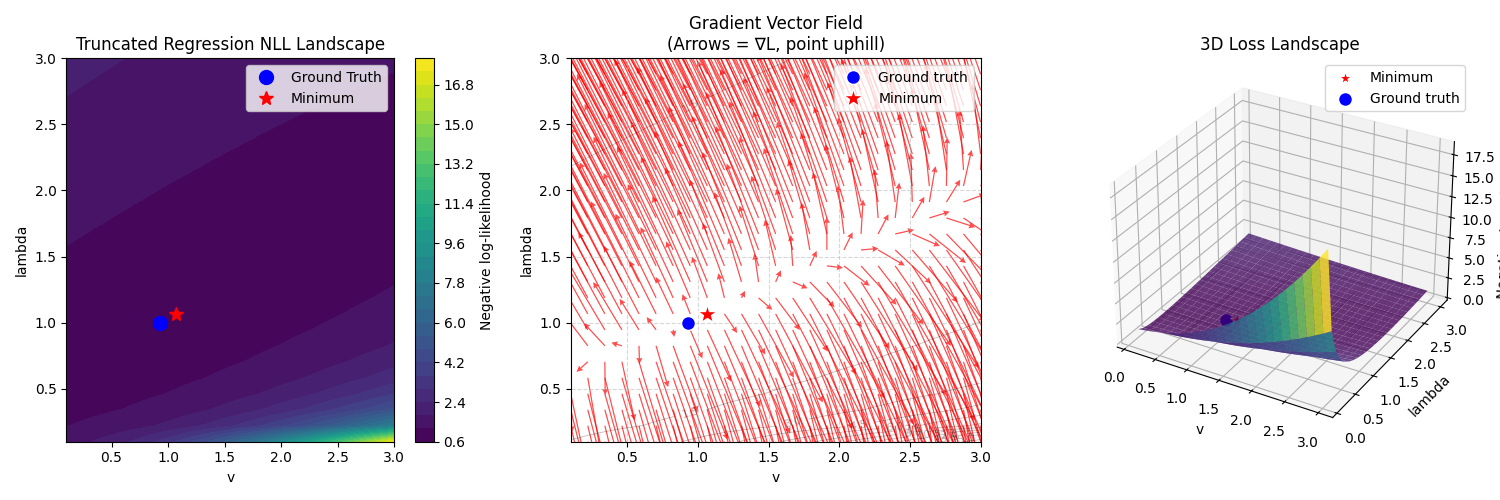

In [429]:
# Find the minimum point 
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
V_min, LAMBDA_min = V_[min_idx], LAMBDA_[min_idx]
min_loss = Z[min_idx]

print(f"Ground truth: v={gt_v.item():.3f}, lambda={gt_lambda_:.3f}")
print(f"Minimum found: v={V_min:.3f}, lambda={LAMBDA_min:.3f}, loss={min_loss:.3f}")
gt_loss = trunc_mse((X_trunc @ W_fit.reshape(1, 1)), Y_trunc, ch.Tensor([[gt_lambda_]]), phi)[0].item()
print(f"\nLoss at ground truth: {gt_loss:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {gt_loss - min_loss:.3f}")

# === Plot the loss landscape ===
fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(131)

cp = ax1.contourf(V_, LAMBDA_, Z, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Negative log-likelihood")

ax1.set_title("Truncated Regression NLL Landscape")
ax1.set_xlabel("v")
ax1.set_ylabel("lambda")

# mark the ground truth
ax1.plot(gt_v.item(), gt_lambda_, 'bo', markersize=10, label="Ground Truth")
ax1.plot(V_min.item(), LAMBDA_min.item(), 'r*', markersize=10, label="Minimum")
ax1.legend()

# Plot 4: Gradient
ax4 = fig.add_subplot(132)

# Plot quiver
Q = ax4.quiver(V_, LAMBDA_, GRAD_V.detach(), GRAD_LAMBDA_,
               color='red', alpha=0.7, width=0.003, scale=1, headwidth=5)

# Add contour of loss for context
contour = ax4.contour(V_, LAMBDA_, Z, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax4.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax4.plot(gt_v.item(), gt_lambda_, 'bo', markersize=10, markeredgecolor='white', label='Ground truth')
ax4.plot(V_min, LAMBDA_min, 'r*', markersize=15, markeredgecolor='white', label='Minimum')

ax4.set_xlabel('v')
ax4.set_ylabel('lambda')
ax4.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax4.legend()
ax4.grid(True, linestyle='--', alpha=0.5)

# Plot 1: 3D surface plot
ax3 = fig.add_subplot(133, projection='3d')
surf = ax3.plot_surface(V_, LAMBDA_, Z, cmap='viridis', alpha=0.8, 
                       linewidth=0, antialiased=True)
ax3.scatter([V_min], [LAMBDA_min], [min_loss], color='red', s=100, 
           label='Minimum', marker='*', edgecolors='white')
ax3.scatter([gt_v.item()], [gt_lambda_], [np.min(Z)], 
           color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
ax3.set_xlabel('v')
ax3.set_ylabel('lambda')
ax3.set_zlabel('Negative Log-Likelihood')
ax3.set_title('3D Loss Landscape')
ax3.legend()

plt.tight_layout()
plt.show()

In [430]:
V_values, LAMBDA_values

(tensor([0.1000, 0.2208, 0.3417, 0.4625, 0.5833, 0.7042, 0.8250, 0.9458, 1.0667,
         1.1875, 1.3083, 1.4292, 1.5500, 1.6708, 1.7917, 1.9125, 2.0333, 2.1542,
         2.2750, 2.3958, 2.5167, 2.6375, 2.7583, 2.8792, 3.0000]),
 tensor([0.1000, 0.2208, 0.3417, 0.4625, 0.5833, 0.7042, 0.8250, 0.9458, 1.0667,
         1.1875, 1.3083, 1.4292, 1.5500, 1.6708, 1.7917, 1.9125, 2.0333, 2.1542,
         2.2750, 2.3958, 2.5167, 2.6375, 2.7583, 2.8792, 3.0000]))

# Run Procedure - 1 Dimension No Intercept

In [431]:
k = 100
W = ch.ones(k)
NOISE_VAR = 3.0
print(f'groud truth W:\n {W}')

X = ch.rand(5000, k)
print(f'ground truth num samples: {X.size(0)}')

Y = X @ W + NOISE_VAR**.5 * ch.randn(X.size(0))

gt_lin_reg = LinearRegression(fit_intercept=True)
gt_lin_reg.fit(X, Y)

gt_ = ch.from_numpy(np.concatenate([gt_lin_reg.coef_.flatten(), gt_lin_reg.intercept_.reshape(1,)]))
gt_noise_var = ch.from_numpy(gt_lin_reg.predict(X) - Y.numpy()).var(0)

gt_lambda_ = 1.0/gt_noise_var
gt_v = gt_ * gt_lambda_

print(f'W fit:\n {gt_.tolist()}')
print(f'noise var fit:\n {gt_noise_var}')

print(f'V fit:\n {gt_v.tolist()}')
print(f'lambda fit:\n {gt_lambda_}')

groud truth W:
 tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])
ground truth num samples: 5000
W fit:
 [0.9912298321723938, 0.9838083982467651, 0.940629243850708, 1.0585070848464966, 0.9390807151794434, 1.0245110988616943, 1.1063437461853027, 0.9755074977874756, 1.036564826965332, 1.1165175437927246, 0.8974525332450867, 1.0865206718444824, 0.8012232780456543, 1.0851560831069946, 0.8749181032180786, 1.0327727794647217, 0.8262646198272705, 1.1105644702911377, 0.9880948066711426, 0.9125545024871826, 1.1208776235580444, 0.9914900064468384, 1.1085948944091797, 0.8727241158485413, 1.018737077713012

In [432]:
from torch.nn import MSELoss
mse_loss = MSELoss()

TRUNC_THRESHOLD = 50

def phi(X): 
    return X > TRUNC_THRESHOLD

trunc_indices = phi(Y).nonzero()
alpha = trunc_indices.size(0) / X.size(0)
print(f'alpha:\n {alpha:.3f}')

Y_trunc = Y[trunc_indices]
X_trunc = X[trunc_indices.flatten()]

trunc_lin_reg = LinearRegression(fit_intercept=True)
trunc_lin_reg.fit(X_trunc, Y_trunc)

# calculate empirical noise variance for regression 
emp_ = ch.from_numpy(np.concatenate([trunc_lin_reg.coef_.flatten(), trunc_lin_reg.intercept_]))
emp_noise_var = (ch.from_numpy(trunc_lin_reg.predict(X_trunc)) - Y_trunc).var(0)
print(f'empirical weights: {emp_}')
print(f'empricial noise variance: {emp_noise_var}')
emp_mse_loss = mse_loss(emp_, gt_)
emp_var_l1 = ch.abs(emp_noise_var - ch.Tensor([NOISE_VAR]))
print(f'emp mse loss: {emp_mse_loss}')
print(f'emp noise var l1: {emp_var_l1.item()}')

alpha:
 0.502
empirical weights: tensor([ 0.6020,  0.7299,  0.6688,  0.6153,  0.6142,  0.6201,  0.7462,  0.6630,
         0.7269,  0.7165,  0.7394,  0.7392,  0.7424,  0.7553,  0.5347,  0.5819,
         0.3649,  0.6358,  0.7047,  0.7541,  0.6926,  0.7302,  0.7518,  0.6291,
         0.6397,  0.7920,  0.5656,  0.7658,  0.6565,  0.5924,  0.8054,  0.6614,
         0.6850,  0.6460,  0.5736,  0.6456,  0.6493,  0.7323,  0.6324,  0.6125,
         0.6341,  0.7641,  0.6573,  0.7580,  0.8515,  0.7810,  0.6040,  0.7571,
         0.5836,  0.7048,  0.6656,  0.8057,  0.6437,  0.8306,  0.7438,  0.6354,
         0.6831,  0.5552,  0.5641,  0.6134,  0.7392,  0.8473,  0.6207,  0.6759,
         0.7218,  0.7175,  0.7966,  0.7691,  0.5834,  0.7093,  0.6838,  0.7569,
         0.6229,  0.6497,  0.5812,  0.7624,  0.4674,  0.6411,  0.6715,  0.3799,
         0.7885,  0.6735,  0.6737,  0.7212,  0.6163,  0.4908,  0.7942,  0.4095,
         0.5869,  0.8082,  0.6927,  0.7209,  0.5828,  0.7218,  0.7326,  0.6690,
       

In [323]:
x_trunc_mu, x_trunc_var = X_trunc.mean(0), X_trunc.var(0)
x_trunc_std = (X_trunc - x_trunc_mu) / (x_trunc_var ** .5)
X_std = (X - x_trunc_mu) / (x_trunc_var ** .5)

y_trunc_mu, y_trunc_var = Y_trunc.mean(0), Y_trunc.var(0)
y_trunc_std = (Y_trunc - y_trunc_mu) / ch.sqrt(y_trunc_var)
scaled_trunc_threshold = (TRUNC_THRESHOLD - y_trunc_mu.item()) / ch.sqrt(y_trunc_var).item()

def phi_emp_scale(X): 
    return X > scaled_trunc_threshold

In [332]:
from delphi.stats import TruncatedLinearRegression 
from delphi import oracle
from delphi.utils.helpers import Parameters

# train algorithm
args = Parameters({
                    'lr': 1e-1,
                    'batch_size': 10,
                    'trials': 1,
                    'verbose': True,
                    'var_lr': 1e-1, 
                    'step_lr': 1000,
                    'step_lr_gamma': 1.0,
                    'gradient_steps': X_trunc.size(0), 
                    'optimizer': 'sgd',
                    'early_stopping': True,
#                     'lr': 5e-1
}) 
trunc_reg = TruncatedLinearRegression(args, 
                                      phi_emp_scale,
                                      alpha, 
                                      fit_intercept=True)
trunc_reg.fit(x_trunc_std, y_trunc_std)

[2025-12-05 13:51:50] INFO - trial: 1
[2025-12-05 13:51:50] INFO - Creating SGD optimizer: {'lr': 0.1, 'momentum': 0.0, 'dampening': 0.0, 'weight_decay': 0.0, 'nesterov': False, 'maximize': False, 'differentiable': False}
[2025-12-05 13:51:50] INFO - [train] epoch=1 step=50 loss=0.0046 grad_norm=2.413e-01
[2025-12-05 13:51:50] INFO - [train] epoch=1 step=100 loss=-0.0248 grad_norm=4.718e-01
[2025-12-05 13:51:50] INFO - [train] epoch=1 step=150 loss=-0.0316 grad_norm=4.201e-01
[2025-12-05 13:51:50] INFO - [val] epoch=1 step=198 loss=-0.0076 grad_norm=2.106e-01
[2025-12-05 13:51:50] INFO - [train] epoch=2 step=200 loss=0.1608 grad_norm=3.265e-01
[2025-12-05 13:51:50] INFO - [train] epoch=2 step=250 loss=-0.0568 grad_norm=5.231e-01
[2025-12-05 13:51:50] INFO - [train] epoch=2 step=300 loss=-0.0423 grad_norm=4.407e-01
[2025-12-05 13:51:50] INFO - [train] epoch=2 step=350 loss=-0.0455 grad_norm=8.468e-01
[2025-12-05 13:51:50] INFO - [val] epoch=2 step=396 loss=-0.0204 grad_norm=4.331e-01
[2

TruncatedLinearRegression()

In [333]:
delphi_coef_ = ch.cat([trunc_reg.best_coef_.flatten(), trunc_reg.best_intercept_[...,None]]) 
delphi_var_ = trunc_reg.best_variance_ * emp_noise_var

delphi_orig = delphi_coef_[:-1]*(ch.sqrt(y_trunc_var)/ch.sqrt(x_trunc_var))
delphi_intercept_orig = y_trunc_mu + ch.sqrt(y_trunc_var) * (delphi_coef_[-1] - (delphi_coef_[:-1] * (x_trunc_mu / ch.sqrt(x_trunc_var))).sum())
delphi_orig_ = ch.cat([delphi_orig, delphi_intercept_orig.reshape(1,)])

delphi_mse = mse_loss(gt_, delphi_orig_).item()
delphi_var_l1 = float(ch.abs(delphi_var_ - gt_noise_var))

print(f'delphi var: {delphi_var_}')
print(f'delphi_coef: {delphi_orig_}')
print(f'delphi mse: {delphi_mse}')
print(f'delphi var l1: {delphi_var_l1}')

delphi var: tensor([1.3537])
delphi_coef: tensor([0.9934, 1.1707, 1.2269, 0.9797, 1.0597, 1.0893, 0.8607, 1.0033, 1.2355,
        0.7776, 0.8970, 1.2997, 0.8172, 0.7740, 0.6951, 1.0176, 0.9362, 1.1686,
        0.8214, 1.0224, 1.0635, 1.0381, 0.9883, 0.7746, 1.0541, 1.1937, 1.2041,
        1.0250, 1.2099, 0.5459, 1.1945, 0.7956, 1.0967, 0.6300, 0.8858, 1.0585,
        1.2398, 1.1851, 1.0935, 0.9511, 1.1035, 0.9199, 0.8123, 1.1214, 0.8695,
        1.1658, 1.0284, 1.2560, 0.8152, 0.9877, 0.8001, 0.9681, 1.1817, 1.2027,
        0.7875, 0.9081, 1.0352, 1.1769, 0.8096, 1.0038, 1.0799, 0.9598, 1.1225,
        1.1965, 1.0901, 0.9209, 1.0398, 1.0811, 1.0228, 0.9557, 0.9061, 1.2240,
        0.8413, 0.9994, 0.7307, 1.4615, 1.4398, 0.9769, 1.3426, 1.0084, 0.8952,
        0.8367, 0.6697, 1.3636, 0.8132, 1.1875, 0.7017, 0.7885, 1.0240, 0.7255,
        1.0654, 0.7562, 0.6752, 0.8935, 0.9383, 0.8590, 1.0079, 1.1974, 1.0411,
        1.0047, 0.0601])
delphi mse: 0.0238826684653759
delphi var l1: 1.45984

In [226]:
min_grad_norm_params = trunc_reg.trainer.train_param_history[trunc_reg.trainer.grad_norms.argmin()]

In [294]:
min_grad_norm_lambda_ = min_grad_norm_params[-1]
min_grad_norm_var = 1.0 / min_grad_norm_lambda_
min_grad_norm_w = min_grad_norm_params[:-1] * min_grad_norm_var 
min_grad_norm_w[:-1] /= trunc_reg.beta

In [295]:
min_grad_norm_lambda_

tensor(0.4271)

In [296]:
delphi_coef_ = min_grad_norm_w.flatten()
delphi_var_ = min_grad_norm_var * emp_noise_var

delphi_orig = delphi_coef_[:-1]*(ch.sqrt(y_trunc_var)/ch.sqrt(x_trunc_var))
delphi_intercept_orig = y_trunc_mu + ch.sqrt(y_trunc_var) * (delphi_coef_[-1] - (delphi_coef_[:-1] * (x_trunc_mu / ch.sqrt(x_trunc_var))).sum())
delphi_orig_ = ch.cat([delphi_orig, delphi_intercept_orig.reshape(1,)])

delphi_mse = mse_loss(gt_, delphi_orig_).item()
delphi_var_l1 = float(ch.abs(delphi_var_ - gt_noise_var))

print(f'delphi var: {delphi_var_}')
print(f'delphi_coef: {delphi_orig_}')
print(f'delphi mse: {delphi_mse}')
print(f'delphi var l1: {delphi_var_l1}')

delphi var: tensor([2.8571])
delphi_coef: tensor([0.3734, 0.3669, 0.3708, 0.3680, 0.3683, 0.3660, 0.3723, 0.3702, 0.3712,
        0.3666, 3.4775])
delphi mse: 1.4435534477233887
delphi var l1: 0.14314508438110352


In [297]:
delphi_noise_var = trunc_reg.best_variance_ 
delphi_coef = trunc_reg.best_coef_
delphi_empirical_weight = trunc_reg.emp_weight
print(f'delphi noise var: {delphi_noise_var}')
print(f'delphi coef: {delphi_coef}')
print(f'delphi empirical weight: {delphi_empirical_weight}')

delphi_mse_loss = mse_loss(delphi_coef, gt_)
delphi_var_l1 = ch.abs(delphi_noise_var - gt_noise_var)
print(f'delphi mse loss: {delphi_mse_loss}')
print(f'delphi var l1: {delphi_var_l1}')

delphi noise var: 1.9442164897918701
delphi coef: tensor([0.2915, 0.1407, 0.2885, 0.2531, 0.1993, 0.1778, 0.2031, 0.1818, 0.1834,
        0.2288])
delphi empirical weight: tensor([[0.1355],
        [0.0633],
        [0.1304],
        [0.1159],
        [0.0917],
        [0.0826],
        [0.0949],
        [0.0861],
        [0.0846],
        [0.1034],
        [0.0012]])


/home/patroklos/base/lib/python3.12/site-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([11])) that is different to the input size (torch.Size([10])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


RuntimeError: The size of tensor a (10) must match the size of tensor b (11) at non-singleton dimension 0

In [300]:
delphi_coef

tensor([0.2915, 0.1407, 0.2885, 0.2531, 0.1993, 0.1778, 0.2031, 0.1818, 0.1834,
        0.2288])

In [184]:
param_history = trunc_reg.trainer.train_param_history.detach()
v_history = param_history[:,0]
lambda_history = param_history[:,1]
var_history = 1/lambda_history
weight_history = (trunc_reg.emp_noise_var * v_history).squeeze(0)

loss_history = trunc_reg.trainer.train_losses.detach()

In [185]:
# === Parameter grids ===
V_values = ch.linspace(.1, 3, 25)
LAMBDA_values = ch.linspace(.1, 3, 25)
V_, LAMBDA_ = ch.meshgrid(V_values, LAMBDA_values)

# === Compute NLL over the grid ===
Z = np.zeros_like(V_)
GRAD_V = ch.zeros_like(V_)
GRAD_LAMBDA_ = ch.zeros_like(LAMBDA_)
for i in range(len(V_values)):
    for j in range(len(LAMBDA_values)):
        lambda_ = LAMBDA_[i, j]
        V_temp =  V_[i, j].reshape(1, 1)
        V_temp.requires_grad = True

        trunc_pred = X_trunc@(V_temp/lambda_)
        trunc_pred.retain_grad()
        loss, pred_grad, lambda_grad = trunc_mse(trunc_pred, Y_trunc, lambda_, phi)
    
        grad_ = (pred_grad / lambda_ * X_trunc).sum(0)

        Z[i, j] = loss
        GRAD_V[i, j] = grad_[0]
        GRAD_LAMBDA_[i, j] = lambda_grad

Ground truth: v=1.050, lambda=1.053
Minimum found: v=1.067, lambda=1.067, loss=0.012

Loss at ground truth: 0.012
Loss at minimum: 0.012
Difference: -0.000


/tmp/ipykernel_176754/1037039396.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  gt_loss = trunc_mse((X_trunc @ W_fit.reshape(1, 1)), Y_trunc, ch.Tensor([gt_lambda_]), phi)[0].item()


<IPython.core.display.Javascript object>


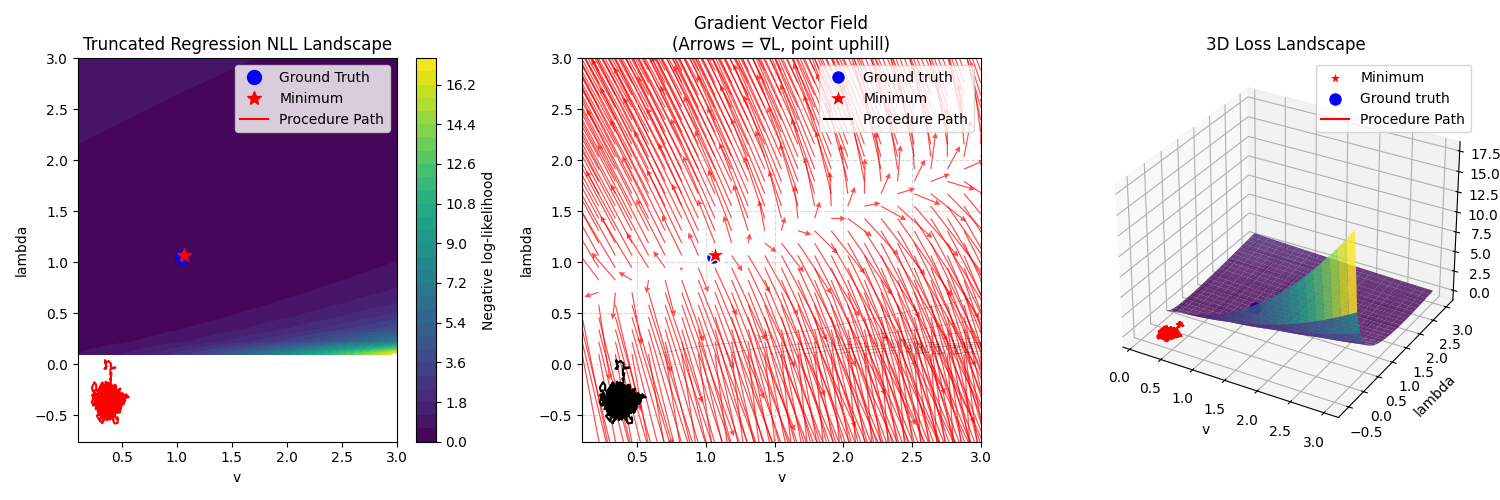

In [186]:
# Find the minimum point 
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
V_min, LAMBDA_min = V_[min_idx], LAMBDA_[min_idx]
min_loss = Z[min_idx]

print(f"Ground truth: v={gt_v.item():.3f}, lambda={gt_lambda_:.3f}")
print(f"Minimum found: v={V_min:.3f}, lambda={LAMBDA_min:.3f}, loss={min_loss:.3f}")
gt_loss = trunc_mse((X_trunc @ W_fit.reshape(1, 1)), Y_trunc, ch.Tensor([gt_lambda_]), phi)[0].item()
print(f"\nLoss at ground truth: {gt_loss:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {gt_loss - min_loss:.3f}")

# === Plot the loss landscape ===
fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(131)

cp = ax1.contourf(V_, LAMBDA_, Z, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Negative log-likelihood")

ax1.set_title("Truncated Regression NLL Landscape")
ax1.set_xlabel("v")
ax1.set_ylabel("lambda")

# mark the ground truth
ax1.plot(gt_v.item(), gt_lambda_, 'bo', markersize=10, label="Ground Truth")
ax1.plot(V_min.item(), LAMBDA_min.item(), 'r*', markersize=10, label="Minimum")
ax1.plot(v_history, lambda_history, color="r", label="Procedure Path")
ax1.legend()

# Plot 4: Gradient
ax4 = fig.add_subplot(132)

# Plot quiver
Q = ax4.quiver(V_, LAMBDA_, GRAD_V.detach(), GRAD_LAMBDA_,
               color='red', alpha=0.7, width=0.003, scale=1, headwidth=5)

# Add contour of loss for context
contour = ax4.contour(V_, LAMBDA_, Z, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax4.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax4.plot(gt_v.item(), gt_lambda_, 'bo', markersize=10, markeredgecolor='white', label='Ground truth')
ax4.plot(V_min, LAMBDA_min, 'r*', markersize=15, markeredgecolor='white', label='Minimum')
ax4.plot(delphi_coef[0], , 'r*', markersize=15, markeredgecolor='white', label='Minimum')
ax4.plot(v_history, lambda_history, color="black", label="Procedure Path")

ax4.set_xlabel('v')
ax4.set_ylabel('lambda')
ax4.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax4.legend()
ax4.grid(True, linestyle='--', alpha=0.5)

# Plot 1: 3D surface plot
ax3 = fig.add_subplot(133, projection='3d')
surf = ax3.plot_surface(V_, LAMBDA_, Z, cmap='viridis', alpha=0.8, 
                       linewidth=0, antialiased=True)
ax3.scatter([V_min], [LAMBDA_min], [min_loss], color='red', s=100, 
           label='Minimum', marker='*', edgecolors='white')
ax3.scatter([gt_v.item()], [gt_lambda_], [np.min(Z)], 
           color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
ax3.plot(v_history, lambda_history, color="r", label="Procedure Path")

ax3.set_xlabel('v')
ax3.set_ylabel('lambda')
ax3.set_zlabel('Negative Log-Likelihood')
ax3.set_title('3D Loss Landscape')
ax3.legend()

plt.tight_layout()
plt.show()

In [72]:
min_dist_var = var_history[ch.abs(var_history - NOISE_VAR).argmin()]
best_var = trunc_reg.best_variance_

In [104]:
w_min_dist_var = (trunc_reg.v*min_dist_var).detach()
w_best = (trunc_reg.v*best_var).detach()
loss, pred_grad, lambda_grad = trunc_mse((X_trunc@w_min_dist_var), Y_trunc, min_dist_var, phi)
loss_best, pred_grad_best, lambda_grad_best = trunc_mse((X_trunc@w_best), Y_trunc, best_var, phi)

In [105]:
print(f'loss: {loss}')
print(f'best loss: {loss_best}')

loss: tensor([0.0003], grad_fn=<MeanBackward1>)
best loss: tensor([0.0003], grad_fn=<MeanBackward1>)


In [106]:
print(f'pred grad: {pred_grad.sum()}')
print(f'pred grad best: {pred_grad_best.sum()}')
print(f'lambda grad: {lambda_grad.sum()}')
print(f'lambda grad best: {lambda_grad_best.sum()}')

pred grad: 0.15081727504730225
pred grad best: 0.1312633752822876
lambda grad: -0.644962728023529
lambda grad best: -0.6925110816955566
